# Part I - FORD-GO-BIKE DATA

## by OLUJIMI FASHOYIN

## Introduction
#### This data set includes information about individual rides made in a bike-sharing system covering the greater San Francisco Bay area. This dataset contains data for the month of february 2019 only.




## Preliminary Wrangling


In [30]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

In [31]:
bike=pd.read_csv('201902-fordgobike-tripdata (1).csv')
bike.sample(10)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
155639,474,2019-02-06 08:39:38.6170,2019-02-06 08:47:33.3120,175.0,49th St at Telegraph Ave,37.835946,-122.262366,176.0,MacArthur BART Station,37.828410,-122.266315,3530,Subscriber,1982.0,Male,No
141923,860,2019-02-07 17:28:32.0000,2019-02-07 17:42:52.5100,6.0,The Embarcadero at Sansome St,37.804770,-122.403234,17.0,Embarcadero BART Station (Beale St at Market St),37.792251,-122.397086,3358,Subscriber,1994.0,Female,No
40173,878,2019-02-22 21:53:00.3820,2019-02-22 22:07:38.8560,270.0,Ninth St at Heinz Ave,37.853489,-122.289415,192.0,37th St at West St,37.826696,-122.271797,6035,Subscriber,1989.0,Male,No
58696,727,2019-02-20 23:16:12.7960,2019-02-20 23:28:20.4450,252.0,Channing Way at Shattuck Ave,37.865847,-122.267443,244.0,Shattuck Ave at Hearst Ave,37.873676,-122.268487,5869,Subscriber,1997.0,Male,Yes
108967,938,2019-02-12 20:33:32.1630,2019-02-12 20:49:10.4120,147.0,29th St at Tiffany Ave,37.744067,-122.421472,58.0,Market St at 10th St,37.776619,-122.417385,4397,Subscriber,1998.0,Female,No
114935,542,2019-02-12 09:03:04.4740,2019-02-12 09:12:06.7730,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,5065,Subscriber,1992.0,Male,No
83951,515,2019-02-17 19:32:11.5570,2019-02-17 19:40:47.1530,310.0,San Fernando St at 4th St,37.335885,-121.885660,279.0,Santa Clara St at 7th St,37.339146,-121.884105,3967,Subscriber,1988.0,Male,Yes
48389,398,2019-02-22 07:52:09.7500,2019-02-22 07:58:48.2780,267.0,Derby St at College Ave,37.861804,-122.253569,171.0,Rockridge BART Station,37.844279,-122.251900,3575,Subscriber,1977.0,Male,No
100539,273,2019-02-14 18:19:24.8810,2019-02-14 18:23:58.0650,176.0,MacArthur BART Station,37.828410,-122.266315,315.0,Market St at 45th St,37.834174,-122.272968,5167,Subscriber,1984.0,Male,No
861,517,2019-02-28 20:12:02.5770,2019-02-28 20:20:39.7460,180.0,Telegraph Ave at 23rd St,37.812678,-122.268773,315.0,Market St at 45th St,37.834174,-122.272968,5083,Subscriber,1992.0,Male,No


bike= pd.read_csv('201902-fordgobike-tripdata (1).csv')
bike.head(10)

In [32]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
duration_sec               183412 non-null int64
start_time                 183412 non-null object
end_time                   183412 non-null object
start_station_id           183215 non-null float64
start_station_name         183215 non-null object
start_station_latitude     183412 non-null float64
start_station_longitude    183412 non-null float64
end_station_id             183215 non-null float64
end_station_name           183215 non-null object
end_station_latitude       183412 non-null float64
end_station_longitude      183412 non-null float64
bike_id                    183412 non-null int64
user_type                  183412 non-null object
member_birth_year          175147 non-null float64
member_gender              175147 non-null object
bike_share_for_all_trip    183412 non-null object
dtypes: float64(7), int64(2), object(7)
memory usage: 22.4+ MB


**Making a copy of the original dataset**

In [33]:
bike_copy=bike.copy()


In [34]:
bike_copy.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


#### Quality issues
 - incorrect datatypes
 - Missing Entries

**Incorrect Dtype correction**

In [35]:
bike_copy.member_gender=bike.member_gender.astype('category')
bike_copy.bike_share_for_all_trip=bike.bike_share_for_all_trip.astype('category')

In [36]:
bike_copy.user_type=bike.user_type.astype('category')
bike_copy.start_time=pd.to_datetime(bike_copy.start_time)
bike_copy.end_time=pd.to_datetime(bike_copy.end_time)

**Test**

In [37]:
bike_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
duration_sec               183412 non-null int64
start_time                 183412 non-null datetime64[ns]
end_time                   183412 non-null datetime64[ns]
start_station_id           183215 non-null float64
start_station_name         183215 non-null object
start_station_latitude     183412 non-null float64
start_station_longitude    183412 non-null float64
end_station_id             183215 non-null float64
end_station_name           183215 non-null object
end_station_latitude       183412 non-null float64
end_station_longitude      183412 non-null float64
bike_id                    183412 non-null int64
user_type                  183412 non-null category
member_birth_year          175147 non-null float64
member_gender              175147 non-null category
bike_share_for_all_trip    183412 non-null category
dtypes: category(3), datetime64[ns](2), float64(7), int64(2), 

In [38]:
#creating a new column for weekdays
bike_copy['weekday']=bike_copy.start_time.dt.weekday_name
day_category=pd.api.types.CategoricalDtype(ordered=True,categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
bike_copy.weekday=bike_copy.weekday.astype(day_category)


In [39]:
#creating a new column to for start time hour
bike_copy['start_time_hour']=bike_copy.start_time.dt.hour.astype(int)

In [40]:
bike_copy.head(11)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,weekday,start_time_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,Thursday,17
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,Thursday,18
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,Thursday,12
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,Thursday,17
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,Thursday,23
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,Thursday,23
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No,Thursday,23
7,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,Thursday,23
8,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,Thursday,23
9,1049,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No,Thursday,23


**Dropping null values**

In [41]:
bike_copy.dropna(inplace=True)

**Test**

In [42]:
bike_copy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 174952 entries, 0 to 183411
Data columns (total 18 columns):
duration_sec               174952 non-null int64
start_time                 174952 non-null datetime64[ns]
end_time                   174952 non-null datetime64[ns]
start_station_id           174952 non-null float64
start_station_name         174952 non-null object
start_station_latitude     174952 non-null float64
start_station_longitude    174952 non-null float64
end_station_id             174952 non-null float64
end_station_name           174952 non-null object
end_station_latitude       174952 non-null float64
end_station_longitude      174952 non-null float64
bike_id                    174952 non-null int64
user_type                  174952 non-null category
member_birth_year          174952 non-null float64
member_gender              174952 non-null category
bike_share_for_all_trip    174952 non-null category
weekday                    174952 non-null category
start_time

### What is the structure of your dataset?

> After a little wrangling and dropping of some null entries, I was left with 174952 records and 16 features.

### What is/are the main feature(s) of interest in your dataset?

> The main feature I'll be investigating is the user_type. I'll be investigating if the the other features are dependent on the user_type

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> I believe that  duration and the bike share for all trips feature would help me determine if the features depend on the user_type

## Univariate Exploration


**To begin i'll start by haing a look at my main feature**

In [43]:
base=sb.color_palette()[0]

In [44]:
#function for labelling 
def labels(x,y,title):
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)

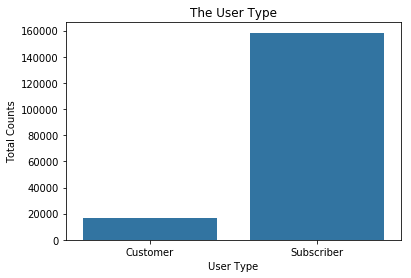

In [45]:
sb.countplot(data=bike_copy,x='user_type',color=base);
labels('User Type','Total Counts','The User Type')


There's a huge gap between the subscibers and the customer. The Subscribers seem to be a lot greater than the customers.

Let me have a look at the member gender

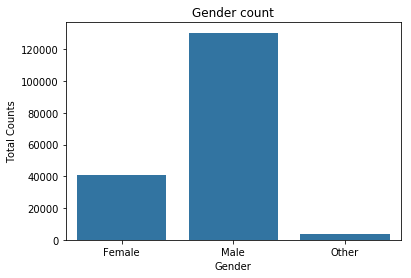

In [46]:

sb.countplot(data=bike_copy,x='member_gender',color=base);
labels('Gender','Total Counts','Gender count')


Most Riders are Male compared to females and the others

plt.hist(data=bike_copy,x='member_birth_year',ec='black',bins=50)
plt.xlabel('Year')
plt.ylabel('Count');


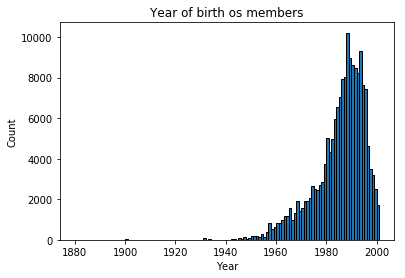

In [47]:
bins=np.arange(1880,bike_copy['member_birth_year'].max()+1,1)
plt.hist(data=bike_copy,x='member_birth_year',ec='black',bins=bins)
labels('Year','Count','Year of birth os members')



The histogram is very skewed to the left With most people who seem to be born betweeb the range of >=1990 and <2000. But there doesn't seem to be a lot people born between 1880-1940.Seems like the number of people at age 74 and above that are still members is very minute

Now I'll be taking a look at the 'duration' variable

In [48]:
bike_copy.duration_sec.max()

84548

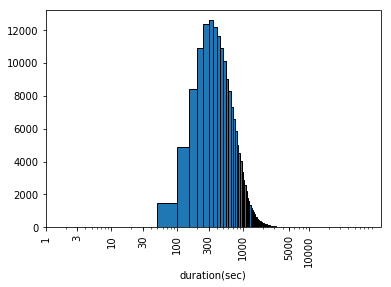

In [49]:
location=[1,3,10,30,100,300,1000,5000,10000]
bins=np.arange(0,bike_copy.duration_sec.max()+50,50)
plt.hist(data=bike_copy,x='duration_sec',bins=bins,ec='black');

plt.xscale('log')
plt.xticks(location,location,rotation=90)
plt.xlabel('duration(sec)');



In [50]:
bike_copy.duration_sec.describe()

count    174952.000000
mean        704.002744
std        1642.204905
min          61.000000
25%         323.000000
50%         510.000000
75%         789.000000
max       84548.000000
Name: duration_sec, dtype: float64

Most bikers spend about 300 seconds before they arrive at their destination.The plot seems to be skewed to the right. But it's maximum duration is quite surprising compared with the graph Seems there's an outrageous amount of outliers here. Let's take a look at that



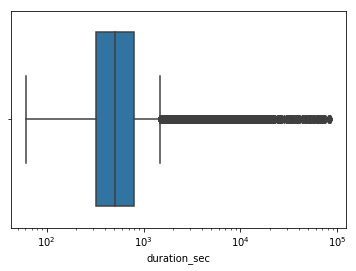

In [51]:
sb.boxplot(data=bike_copy,x='duration_sec')
plt.xscale('log');

In [52]:
#getting the outliers
Q1= 323
Q3=789
IQR=Q3-Q1
high_outliers= Q3+(IQR*1.5)
low_outliers=Q1-(IQR*1.5)
print('ouliers =',high_outliers,'and',low_outliers)

print('total numer of outliers =',bike_copy[bike_copy.duration_sec>=high_outliers].shape[0])
bike_copy[bike_copy.duration_sec>=high_outliers]

ouliers = 1488.0 and -376.0
total numer of outliers = 9346


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,weekday,start_time_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,Thursday,17
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,Thursday,12
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,Thursday,17
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,Thursday,23
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,Thursday,23
7,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,Thursday,23
8,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,Thursday,23
42,1554,2019-02-28 23:20:24.089,2019-02-28 23:46:19.019,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,284.0,Yerba Buena Center for the Arts (Howard St at ...,37.784872,-122.400876,5411,Subscriber,1972.0,Male,No,Thursday,23
55,3478,2019-02-28 22:39:35.020,2019-02-28 23:37:33.342,11.0,Davis St at Jackson St,37.797280,-122.398436,11.0,Davis St at Jackson St,37.797280,-122.398436,1846,Subscriber,1995.0,Male,No,Thursday,22
56,3140,2019-02-28 22:44:53.503,2019-02-28 23:37:14.090,11.0,Davis St at Jackson St,37.797280,-122.398436,11.0,Davis St at Jackson St,37.797280,-122.398436,3040,Subscriber,1983.0,Female,No,Thursday,22


After investigation of the outliers, there does not seem to be any wrong input of ouliers

Next is the day of the week

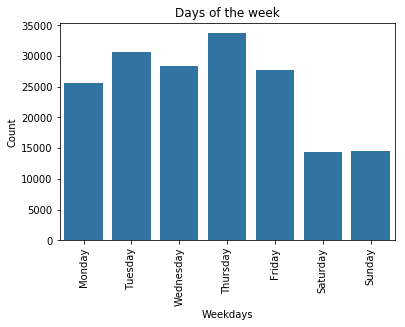

In [53]:
sb.countplot(data=bike_copy, x='weekday',color=base)
plt.xticks(rotation=90)
labels('Weekdays','Count','Days of the week')


It seems like there are more active bikers on Thursdays(at the middle of the week) while the weekends have the least number of active bikers

Next up would be the member year

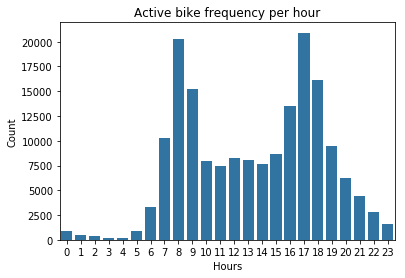

In [54]:
ticks=[1,3,5,8,10,13,15,17,20]
sb.countplot(data=bike_copy,x='start_time_hour',color=base)
labels('Hours','Count','Active bike frequency per hour')


As seen in the chart, A lot of bikes are mostly active during at 8am during the start of work hours and 5pm during end of work

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> According to my Univariate  exploration, There are a lot of subscribers compared to customers of the services.and the duration variable seems to be skewed to the right, meaning not many users go far distances that could take them beyond 1000seconds of duration time.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The duration feature's distribution was quite unusual at first. The outliers seem to be outrageous but after taken a look at the outlier, I discovered ther was actually nothing wrong with them. 

> I also had discovered some quality issues like wrong data types which I had to correct and null entries which I later dropped in order to get an accurate analysis

## Bivariate Exploration


Now I'll be looking at the relationships between different features


### Duration against  User_type(How long do customers spend before arriving at the final destination compared to subscribers?)

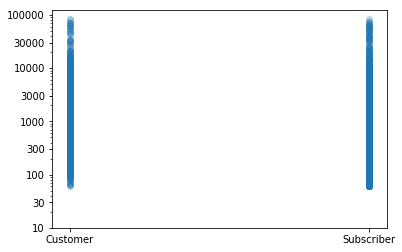

In [55]:
tick=[10,30,100,300,1000,3000,10000,30000,100000]
plt.scatter(data=bike_copy,y='duration_sec',x='user_type',color=base,alpha=1/9)
plt.yscale('log')
plt.yticks(tick,tick);

There doesn't seem to be much difference between the duration time of the customer and subscriber but this will be investigated more later on

### Start_time_hour against User_type( Are there any trends between the customer start time and Subscriber Start time?)

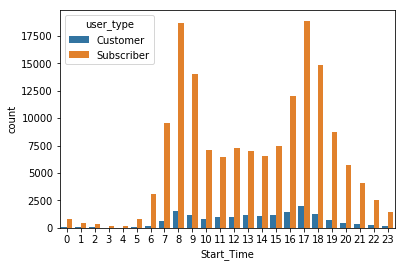

In [56]:
sb.countplot(data=bike_copy,x='start_time_hour',hue='user_type')
plt.xlabel('Start_Time');

The start customer and  subscriber type since to be following the same trend in the sense that both  use the bike services by 8am and 5pm which does make sense cause those are the start and end of work hours when people are either heading to work or heading from work.

/opt/conda/lib/python3.6/site-packages/seaborn/axisgrid.py:703: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


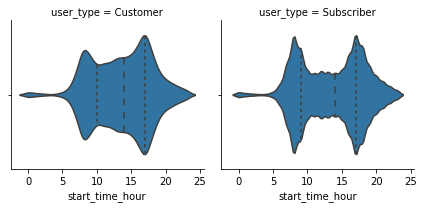

In [57]:

g=sb.FacetGrid(data=bike_copy,col='user_type')
g.map(sb.violinplot,'start_time_hour',inner='quartile')
plt.xticks();

This helps us look at the the individual type more closely. The customers tend to use the bike service more often from hours between 3pm and 8pm(close of work hour, rush hour) than in the morning(5am-10am) during the start of work hours but this is not the case of the subscribers. The subscribers tend to use it at the same rate in the morning and evening during rush hours. This may be because that may be the main transportation for the subscribers but pthe customers probably have another alternative means of transporting themselves in the morning than in the evening.

### Member_Gender x Weekday

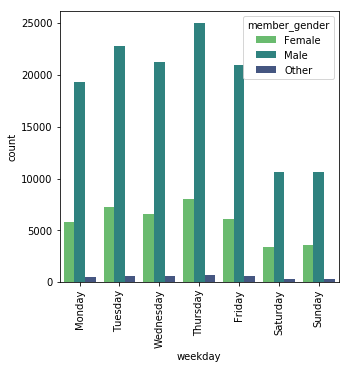

In [58]:
plt.rcParams["figure.figsize"] = (5,5)

sb.countplot(data=bike_copy, hue='member_gender',x='weekday',color=base,palette='viridis_r')
plt.xticks(rotation=90);


The trend of the Male bikers is quite similar to the Female. The frequency seems to be highest on Thursday and lowest on Saturday and Sunday which both have about the same frequency

### Weekday x User_type

''

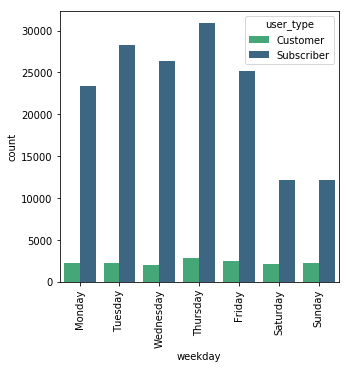

In [59]:
sb.countplot(data=bike_copy, hue='user_type',x='weekday',palette='viridis_r')
plt.xticks(rotation=90)
;

The riders seem to use the service mostly on Thursdays. This is quite interesting because I personally would have expected more bike rides to be on mondays as monday is the starting of the week

### Weekday x User_type

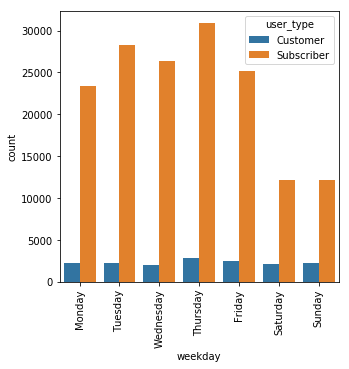

In [60]:
sb.countplot(data=bike_copy,x='weekday',hue='user_type')
plt.xticks(rotation=90);

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> The customers tend to use the bike service more often from hours between 3pm and 8pm(close of work hour, rush hour) than in the morning(5am-10am) during the start of work hours but this is not the case of the subscribers. The subscribers tend to use it at the same rate in the morning and evening during rush hours.
### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

>Both Male and Female bikers seem to use the service on Thursdays. Don't know why but I  find it interesting

## Multivariate Exploration


### How long do users spend riding depending on start_time?

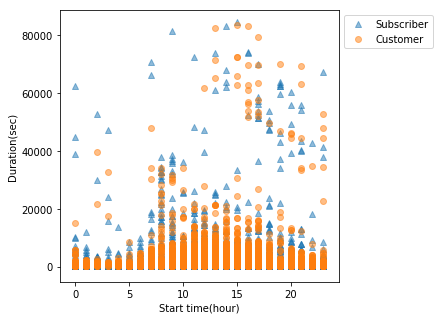

In [61]:
Usertype_markers=[['Subscriber','^'],
                 ['Customer','o']]
for usertype, marker in Usertype_markers:
    bike_new=bike_copy[bike_copy.user_type==usertype]
    plt.scatter(data=bike_new,y='duration_sec',x='start_time_hour',marker=marker,alpha=0.5)
    plt.legend(['Subscriber','Customer'],bbox_to_anchor=(1,1))
plt.xlabel('Start time(hour)')
plt.ylabel('Duration(sec)');

The plot shows that  most customers spend shorter durations and start their between 8am -5pm while the subscribers spend more duration time and their start time seems to be most during work rush hours as indicated in the bivariat section

### How long and during what day do bikers ride most depending on the type of User?

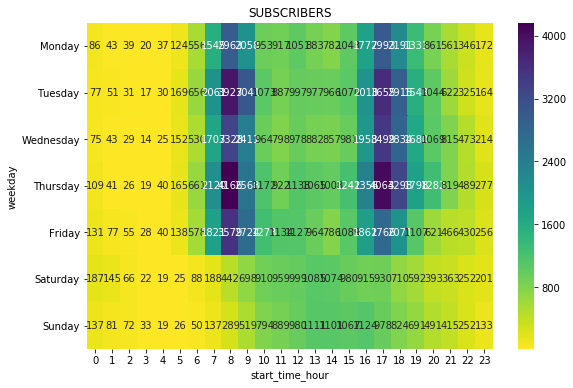

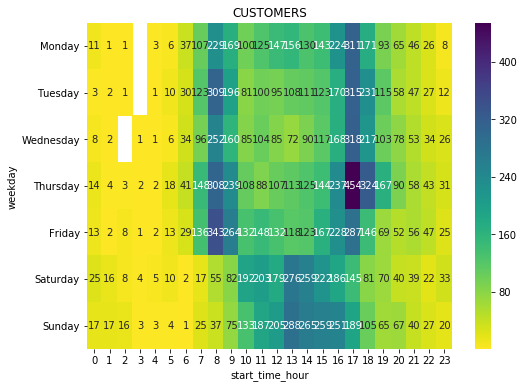

In [63]:
#setting the size
plt.figure(figsize = [20, 6])

plt.subplot(1,2,1)
#getting the set for subscribers
first=bike_copy[bike_copy.user_type=='Subscriber']
#grouping the features of intereset and by its size
s_set=first.groupby(['weekday','start_time_hour']).size()
#reshaping s_set
s_set=s_set.reset_index(name='size')
s_set=s_set.pivot(index='weekday',columns='start_time_hour',values='size')
sb.heatmap(s_set,annot=True,fmt='d',cmap='viridis_r');
plt.title('SUBSCRIBERS')
plt.figure(figsize = [18, 6])

plt.subplot(1,2,2)
#getting the set for subscribers
second=bike_copy[bike_copy.user_type=='Customer']
#grouping the features of intereset and by its size
c_set=second.groupby(['weekday','start_time_hour']).size()
#reshaping s_set
c_set=c_set.reset_index(name='size')
c_set=c_set.pivot(index='weekday',columns='start_time_hour',values='size')
sb.heatmap(c_set,annot=True,fmt='g',cmap='viridis_r')
plt.title('CUSTOMERS');


The customers don't seem to ride as often as the subscribers. The customers tend to ride on weekdays less but more often than the Subscribers(Note this is in relation to each of the user types total population as the Subscribers are a lot more than the Customers).
According to the plot both categories seem to use it more during weekdays but most on thursdays.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

>In this part of the investigation, we observe that customers spend shorter durations and start their between 8am -5pm while the subscribers spend more duration time and their start time seems to be most during work rush hours as indicated in the bivariat section. 

### Were there any interesting or surprising interactions between features?

> In this section I noticed that though the population of the customers are not much but relative to their total population, they spend more time during weekends than the Subscribers. But this is only relative to each categories population

## Conclusions
>In summary, I have seen that the frequency of bike use actually does depend on the user type as subscribers tend to use it more often and for longer durations than customers
